#Worksheet 05
#Alina Shrestha
#2408564

# Task 1: Data Understanding & Visualization

In [24]:
from google.colab import files

uploaded = files.upload()

Saving FruitinAmazon.zip to FruitinAmazon (1).zip


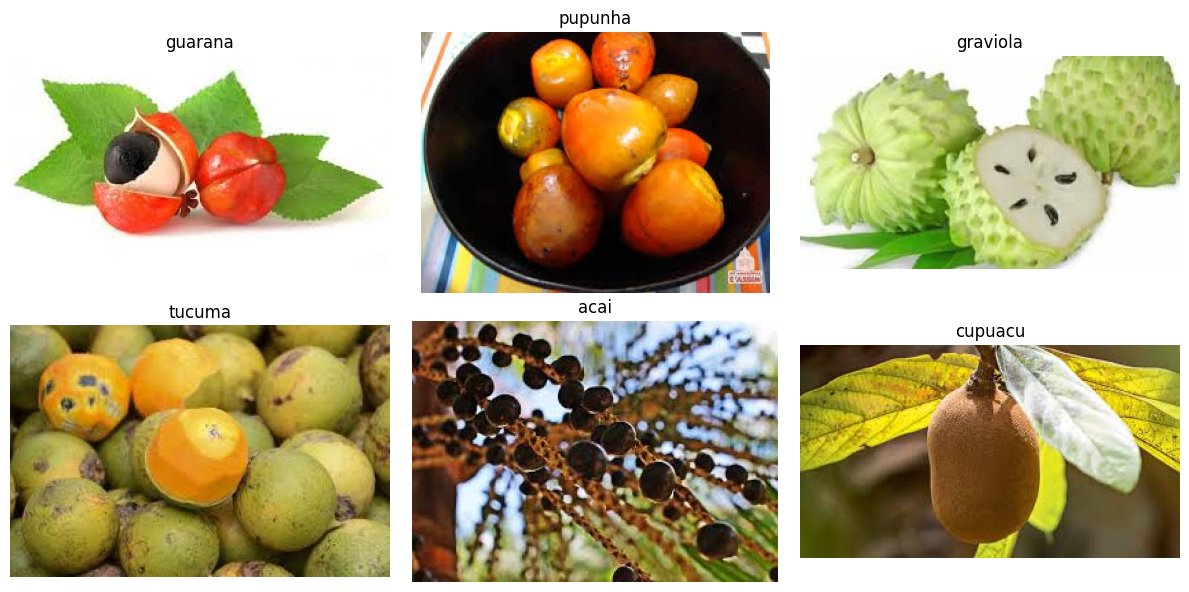

In [30]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Step 1: Get class folders
classes = os.listdir(train_dir)

images = []
labels = []

# Step 2: Pick one random image from each class
for cls in classes:
    class_path = os.path.join(train_dir, cls)

    if os.path.isdir(class_path):
        img_name = random.choice(os.listdir(class_path))
        img_path = os.path.join(class_path, img_name)

        img = Image.open(img_path)
        images.append(img)
        labels.append(cls)

# Step 3: Display in grid (2 rows)
num_images = len(images)
cols = num_images // 2 + num_images % 2

plt.figure(figsize=(12, 6))

for i in range(num_images):
    plt.subplot(2, cols, i+1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
print(os.listdir(train_dir))

['guarana', 'pupunha', 'graviola', 'tucuma', 'acai', 'cupuacu']


#corrupted image

In [32]:
from PIL import Image
import os

corrupted_images = []

# Iterate through each class folder
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        for img_name in os.listdir(class_path):
            image_path = os.path.join(class_path, img_name)

            try:
                # Try opening image
                img = Image.open(image_path)
                img.verify()  # Check if image is valid

            except (IOError, SyntaxError):
                # If corrupted → remove it
                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

# Final report
if len(corrupted_images) == 0:
    print("No corrupted images found.")
else:
    print("\nTotal corrupted images removed:", len(corrupted_images))

No corrupted images found.


#Task 2: Loading and Preprocessing Image Data in keras:

In [34]:
import tensorflow as tf

# Parameters
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2

# Normalization layer
rescale = tf.keras.layers.Rescaling(1./255)

# Training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)

# SAVE CLASS NAMES HERE (before map)
class_names = train_ds.class_names
num_classes = len(class_names)

# Apply normalization
train_ds = train_ds.map(lambda x, y: (rescale(x), y))


# Validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)

# Apply normalization
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


#Task3: Build CNN

In [36]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Build CNN model
model = models.Sequential()

# Convolutional Layer 1
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='same',
    strides=1,
    activation='relu',
    input_shape=(128, 128, 3)
))

# Pooling Layer 1
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

# Convolutional Layer 2
model.add(layers.Conv2D(
    filters=32,
    kernel_size=(3, 3),
    padding='same',
    strides=1,
    activation='relu'
))

# Pooling Layer 2
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))


# Fully Connected Network
model.add(layers.Flatten())

# Hidden Layer 1 (Input hidden layer)
model.add(layers.Dense(64, activation='relu'))

# Hidden Layer 2
model.add(layers.Dense(128, activation='relu'))

# Output Layer
model.add(layers.Dense(num_classes, activation='softmax'))


# Model Summary
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4:compile

In [39]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Task 5: Train

In [44]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/step - accuracy: 0.8727 - loss: 0.6819
Epoch 1: val_accuracy improved from None to 0.61111, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 559ms/step - accuracy: 0.8056 - loss: 0.9047 - val_accuracy: 0.6111 - val_loss: 0.7767
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.8866 - loss: 0.2975
Epoch 2: val_accuracy did not improve from 0.61111
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 0.8472 - loss: 0.3602 - val_accuracy: 0.5000 - val_loss: 1.1179
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step - accuracy: 0.9294 - loss: 0.3692
Epoch 3: val_accuracy improved from 0.61111 to 0.88889, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 453ms/step - accuracy: 0.9444 - loss: 0.3469 - val_accuracy: 0.8889 - val_loss: 0.5676
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - accuracy: 0.9902 - loss: 0.2739
Epoch 4: val_accuracy improved from 0.88889 to 1.00000, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 476ms/step - accuracy: 0.9861 - loss: 0.2924 - val_accuracy: 1.0000 - val_loss: 0.3255
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.9699 - loss: 0.2501
Epoch 5: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step - accuracy: 0.9722 - loss: 0.2437 - val_accuracy: 0.8333 - val_loss: 0.4567
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 578ms/step - accuracy: 0.9595 - loss: 0.2098
Epoch 6: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 758ms/step - accuracy: 0.9722 - loss: 0.1760 - val_accuracy: 0.8889 - val_loss: 0.3780
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 342ms/step - accuracy: 1.0000 - loss: 0.0958
Epoch 7: val_accuracy did not improve from 1.00000
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 420ms/step - accuracy: 1.0000 - loss: 0.0831 - val_accuracy: 0.8889 - val_loss: 0.2602
Epoch 8/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 1.0000 - loss: 0.047

#Task 6: Evaluate Model





In [45]:
test_loss, test_acc = model.evaluate(val_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.9444 - loss: 0.1712
Test Loss: 0.1711656004190445
Test Accuracy: 0.9444444179534912


# TASK 7: Save & Load Model

In [70]:
model.save("cnn_model.keras")
print("Model saved successfully!")

Model saved successfully!


#load model

In [69]:
loaded_model = tf.keras.models.load_model("cnn_model.keras")

#Re-evaluate the loaded model

In [48]:
loss, acc = loaded_model.evaluate(val_ds)
print("Loaded Model Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step - accuracy: 0.9444 - loss: 0.1712
Loaded Model Accuracy: 0.9444444179534912


#TASK 8: Predictions + Classification Report

In [71]:
import numpy as np

y_true = np.concatenate([y for x, y in val_ds], axis=0)

#model prediction

In [56]:
y_pred = model.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


In [57]:
class_names = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir
).class_names

Found 90 files belonging to 6 classes.


In [58]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred_classes,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
))

              precision    recall  f1-score   support

        acai       0.00      0.00      0.00         0
     cupuacu       0.00      0.00      0.00         0
    graviola       0.00      0.00      0.00         0
     guarana       0.00      0.00      0.00         0
     pupunha       1.00      0.67      0.80         3
      tucuma       1.00      1.00      1.00        15

    accuracy                           0.94        18
   macro avg       0.33      0.28      0.30        18
weighted avg       1.00      0.94      0.97        18



#confusion matrix

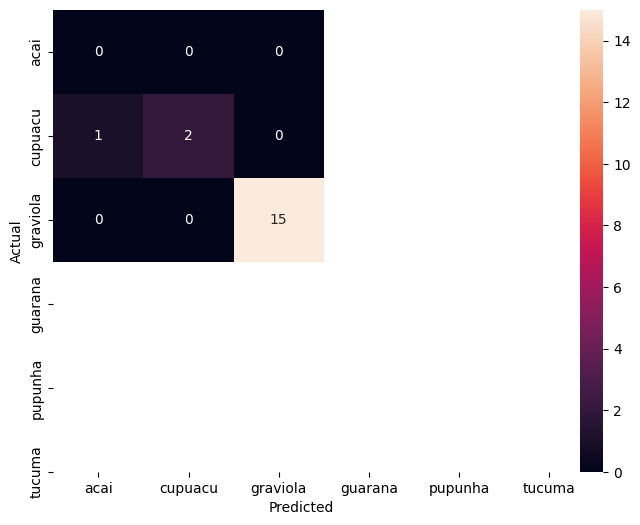

In [59]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# TASK 9: Plot Accuracy & Loss Graphs

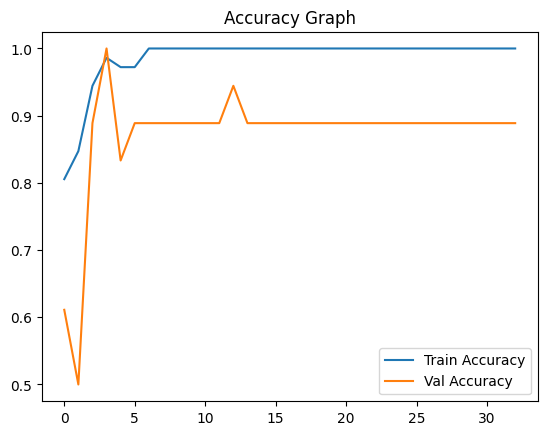

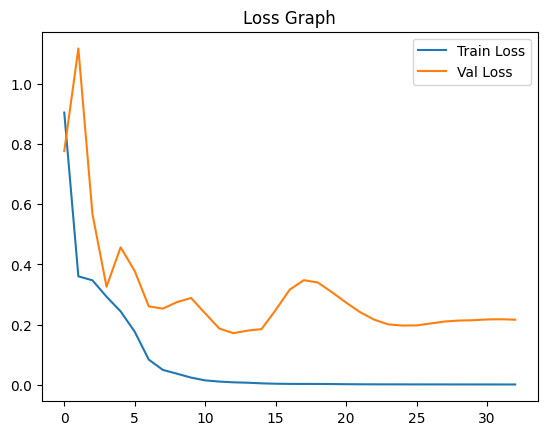

In [60]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Graph")
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Graph")
plt.legend()
plt.show()